# S6E9 - Predicting Electric Vehicle Purchases
## Score: .94177

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Load Data

In [2]:
train = pd.read_csv("playground-series-s6e9/train.csv")
test = pd.read_csv("playground-series-s6e9/test.csv")
sample_submission = pd.read_csv("playground-series-s6e9/sample_submission.csv")

train.shape, test.shape

((668665, 15), (286571, 14))

## Overview

In [3]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

## Missing Values

In [5]:
train.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

## Target Distribution

,count
Will_Buy_EV,
No,551886
Yes,116779


,proportion
Will_Buy_EV,
No,0.825355
Yes,0.174645


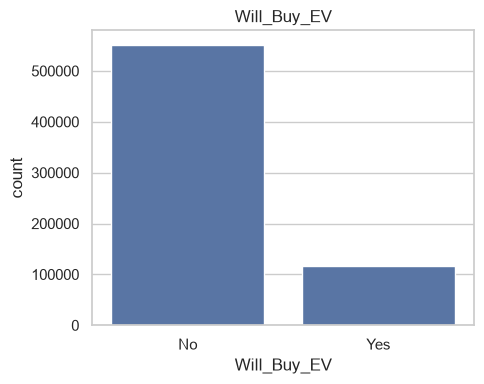

In [6]:
target_counts = train["Will_Buy_EV"].value_counts()
target_pct = train["Will_Buy_EV"].value_counts(normalize=True)

display(target_counts.to_frame("count"))
display(target_pct.to_frame("proportion"))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train, x="Will_Buy_EV", order=target_counts.index, ax=ax)
ax.set_title("Will_Buy_EV")
plt.tight_layout()
plt.show()

## Numeric Features

In [7]:
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.drop("id")
train[numeric_cols].describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


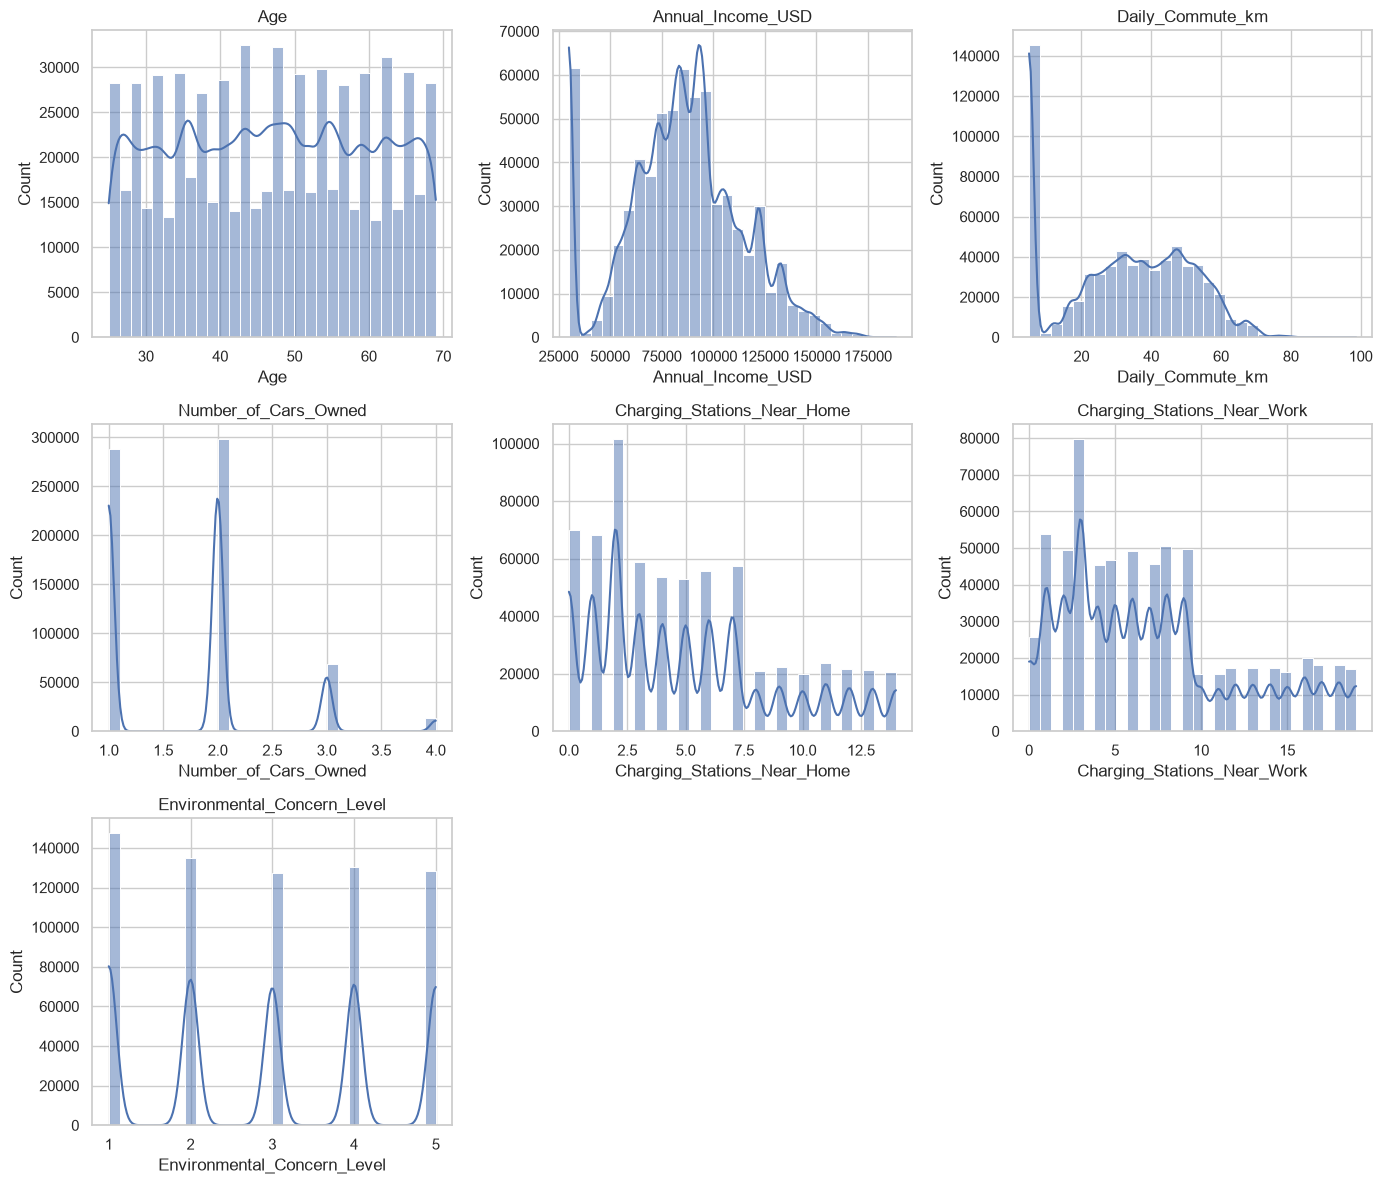

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.histplot(train[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Categorical Features

In [9]:
cat_cols = [c for c in train.columns if c not in numeric_cols and c not in ["id", "Will_Buy_EV"]]
cat_cols

['Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level']

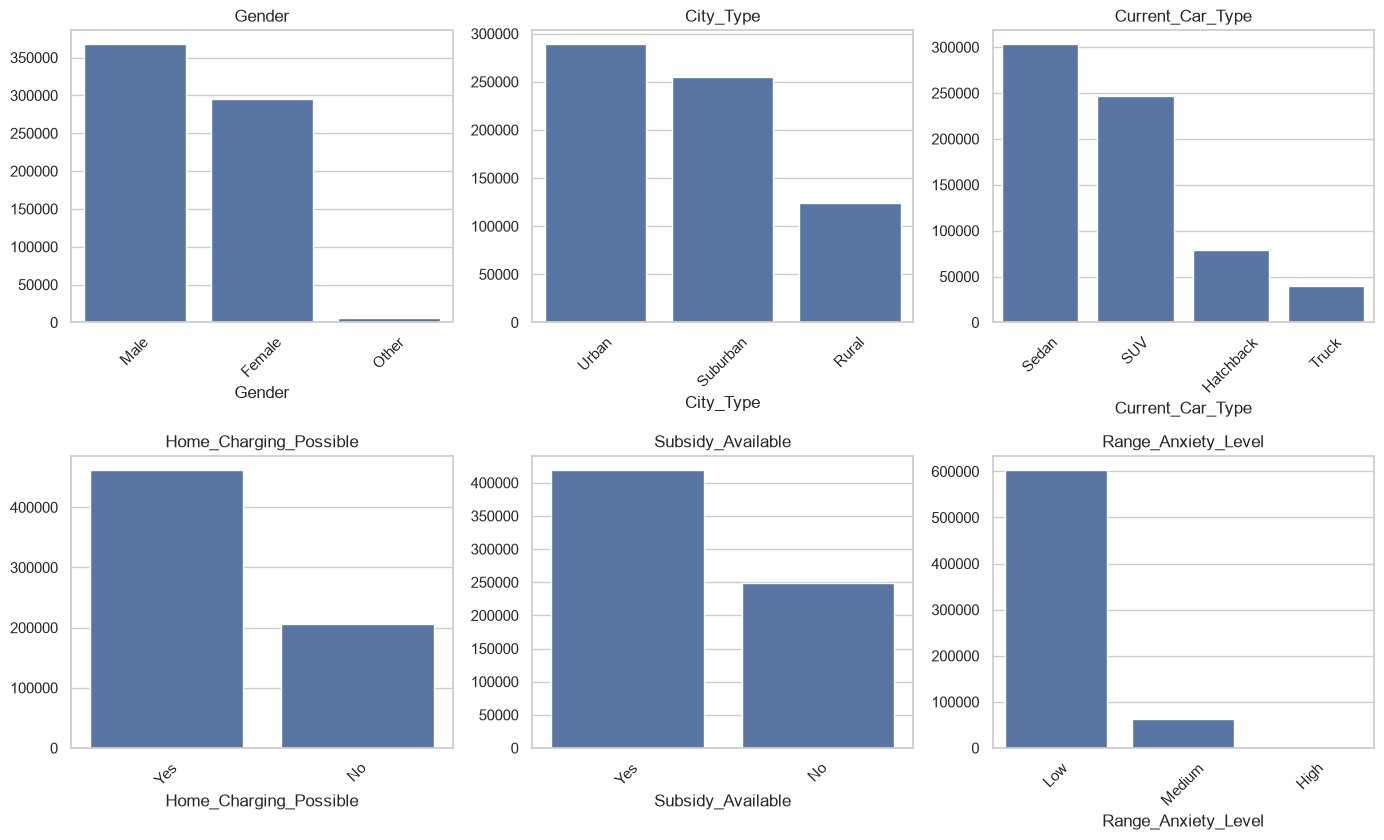

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    counts = train[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation Matrix

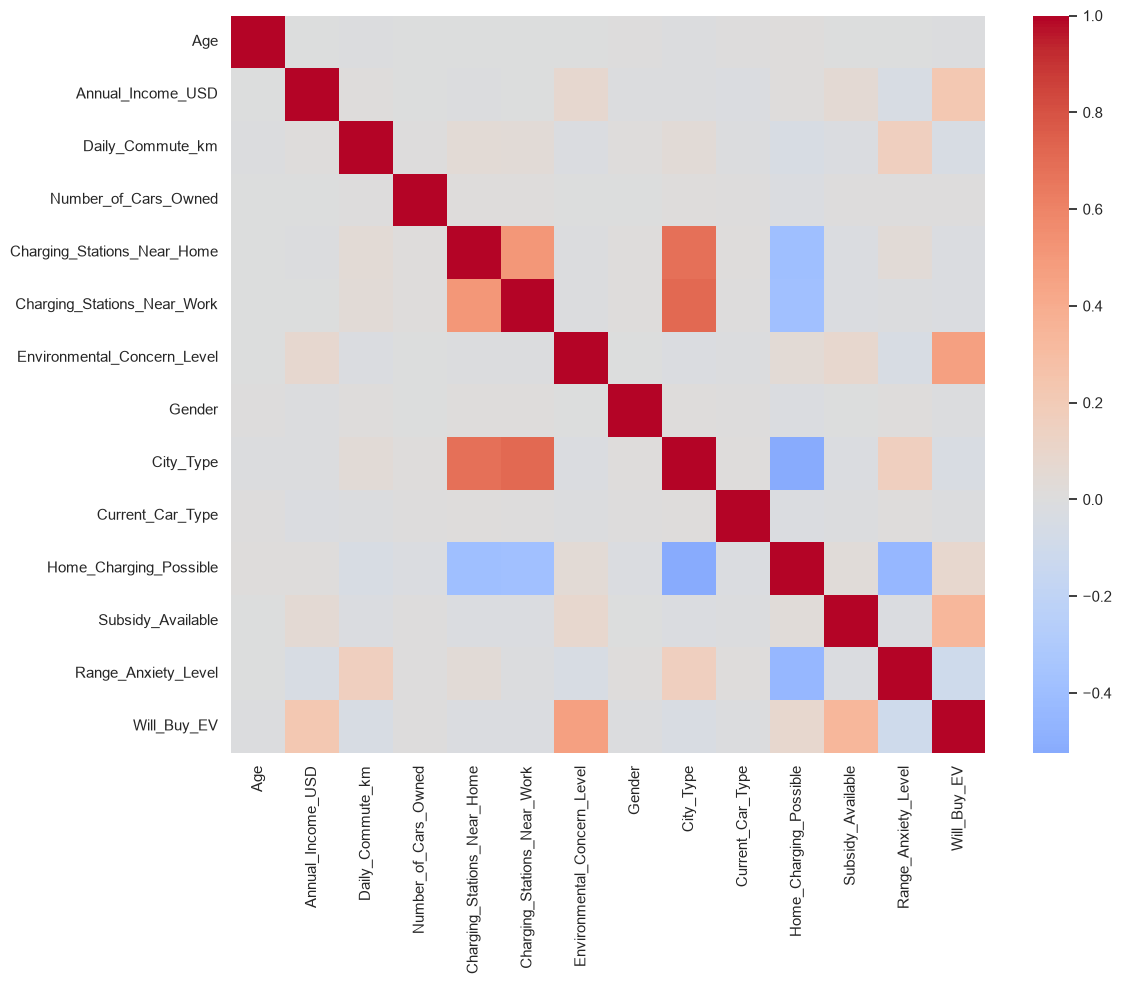

In [11]:
corr_df = train.drop(columns=["id"]).copy()
corr_df["Will_Buy_EV"] = corr_df["Will_Buy_EV"].map({"Yes": 1, "No": 0})

for col in cat_cols:
    corr_df[col] = corr_df[col].astype("category").cat.codes

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
plt.tight_layout()
plt.show()

## Baseline

In [12]:
feature_cols = [c for c in train.columns if c not in ["id", "Will_Buy_EV"]]
cat_cols = [c for c in feature_cols if train[c].dtype not in ["int64", "float64"]]

X = train[feature_cols].copy()
y = (train["Will_Buy_EV"] == "Yes").astype(int)
X_test = test[feature_cols].copy()

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
encoder.fit(pd.concat([X[cat_cols], X_test[cat_cols]], axis=0))
X[cat_cols] = encoder.transform(X[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train Model

In [13]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
)

roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

C:\Users\sshuser\AppData\Roaming\Python\Python311\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


0.9415221992530132

## Submission

In [14]:
final_model = lgb.LGBMClassifier(
    n_estimators=model.best_iteration_,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

final_model.fit(X, y)

preds = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"id": test["id"], "Will_Buy_EV": preds})

## Improvements

- Expanded domain features and exact subsidy / environmental concern crosses
- Multi-smoothing target encoding for LightGBM and XGBoost
- CatBoost trained on native categoricals with a different feature view
- 10-fold multi-seed LightGBM plus 5-fold XGBoost and CatBoost
- OOF-weighted blend of the three model families for the final submission

## Feature Engineering

In [15]:
CAT_COLS = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level",
]

PAIR_COLS = [
    ("Subsidy_Available", "Range_Anxiety_Level"),
    ("Subsidy_Available", "Home_Charging_Possible"),
    ("Subsidy_Available", "Environmental_Concern_Level"),
    ("Range_Anxiety_Level", "Home_Charging_Possible"),
    ("City_Type", "Current_Car_Type"),
]

TRIPLE_COLS = [
    ("Subsidy_Available", "Environmental_Concern_Level", "Range_Anxiety_Level"),
    ("Subsidy_Available", "Environmental_Concern_Level", "Home_Charging_Possible"),
]

RANGE_ANXIETY_MAP = {"Low": 0, "Medium": 1, "High": 2}


def build_features(df):
    out = df.copy()
    out["Total_Charging"] = (
        out["Charging_Stations_Near_Home"] + out["Charging_Stations_Near_Work"]
    )
    out["Home_Work_Charging_Diff"] = (
        out["Charging_Stations_Near_Home"] - out["Charging_Stations_Near_Work"]
    )
    out["Home_Work_Charging_Ratio"] = out["Charging_Stations_Near_Home"] / (
        out["Charging_Stations_Near_Work"] + 1
    )
    out["Income_per_Car"] = out["Annual_Income_USD"] / (out["Number_of_Cars_Owned"] + 1)
    out["Commute_per_Car"] = out["Daily_Commute_km"] / (out["Number_of_Cars_Owned"] + 1)
    out["Stations_per_Car"] = out["Total_Charging"] / (out["Number_of_Cars_Owned"] + 1)
    out["Has_Subsidy"] = (out["Subsidy_Available"] == "Yes").astype(np.int8)
    out["Can_Charge"] = (out["Home_Charging_Possible"] == "Yes").astype(np.int8)
    out["Anx_ord"] = out["Range_Anxiety_Level"].map(RANGE_ANXIETY_MAP)
    out["Low_Anx"] = (out["Anx_ord"] == 0).astype(np.int8)
    out["High_Anx"] = (out["Anx_ord"] == 2).astype(np.int8)
    out["Env"] = out["Environmental_Concern_Level"]
    out["High_Env"] = (out["Env"] >= 4).astype(np.int8)
    out["Very_High_Env"] = (out["Env"] >= 5).astype(np.int8)
    out["Income_k"] = out["Annual_Income_USD"] / 1000
    out["Income_log"] = np.log1p(out["Annual_Income_USD"])
    out["Commute_log"] = np.log1p(out["Daily_Commute_km"])
    out["Env_sq"] = out["Env"] ** 2
    out["Env_cb"] = out["Env"] ** 3
    out["Age_sq"] = out["Age"] ** 2
    out["Ready_to_Buy"] = out["Has_Subsidy"] * out["Can_Charge"] * out["Low_Anx"]
    out["Subsidy_Env"] = out["Has_Subsidy"] * out["Env"]
    out["Subsidy_Env_sq"] = out["Has_Subsidy"] * out["Env_sq"]
    out["Subsidy_High_Env"] = out["Has_Subsidy"] * out["High_Env"]
    out["No_Subsidy_High_Env"] = (1 - out["Has_Subsidy"]) * out["High_Env"]
    out["Subsidy_Income"] = out["Has_Subsidy"] * out["Income_k"]
    out["Subsidy_Charging"] = out["Has_Subsidy"] * out["Total_Charging"]
    out["Subsidy_Low_Anx"] = out["Has_Subsidy"] * out["Low_Anx"]
    out["Charge_Env"] = out["Can_Charge"] * out["Env"]
    out["Charge_Subsidy"] = out["Can_Charge"] * out["Has_Subsidy"]
    out["Env_Low_Anx"] = out["Env"] * out["Low_Anx"]
    out["Env_High_Anx"] = out["Env"] * out["High_Anx"]
    out["Income_Env"] = out["Income_k"] * out["Env"]
    out["Commute_Env"] = out["Daily_Commute_km"] * out["Env"]
    out["Stations_Env"] = out["Total_Charging"] * out["Env"]
    out["Age_Env"] = out["Age"] * out["Env"]
    out["Subsidy_Score"] = out["Has_Subsidy"] * (
        out["Env"] + out["Can_Charge"] + out["Low_Anx"] + out["High_Env"]
    )
    out["Wealthy_Green"] = (out["Income_k"] > 90).astype(np.int8) * out["Env"]
    out["Car_Light"] = (out["Number_of_Cars_Owned"] <= 1).astype(np.int8)

    for left, right in PAIR_COLS:
        pair_name = f"{left}__{right}"
        out[pair_name] = out[left].astype(str) + "_" + out[right].astype(str)

    for left, middle, right in TRIPLE_COLS:
        triple_name = f"{left}__{middle}__{right}"
        out[triple_name] = (
            out[left].astype(str)
            + "_"
            + out[middle].astype(str)
            + "_"
            + out[right].astype(str)
        )

    feature_cols = [c for c in out.columns if c not in ["id", "Will_Buy_EV"]]
    return out[feature_cols]


X = build_features(train)
X_test = build_features(test)
y = (train["Will_Buy_EV"] == "Yes").astype(int).values
PAIR_FEATURE_COLS = [f"{left}__{right}" for left, right in PAIR_COLS]
TRIPLE_FEATURE_COLS = [f"{left}__{middle}__{right}" for left, middle, right in TRIPLE_COLS]
ENCODE_COLS = CAT_COLS + PAIR_FEATURE_COLS + TRIPLE_FEATURE_COLS
CATBOOST_CAT_COLS = CAT_COLS + PAIR_FEATURE_COLS + TRIPLE_FEATURE_COLS

print(f"train rows: {len(train):,}")
print(f"test rows: {len(test):,}")
print(f"raw features: {X.shape[1]}")
print(f"encode keys: {len(ENCODE_COLS)}")
print(f"target rate: {y.mean():.6f}")

train rows: 668,665
test rows: 286,571
raw features: 59
encode keys: 13
target rate: 0.174645


## Improved Model

In [16]:
def add_target_encoding(
    X_train,
    y_train,
    X_valid,
    X_test,
    cat_cols,
    smoothings=(5, 20, 80),
):
    global_mean = y_train.mean()
    X_train = X_train.copy()
    X_valid = X_valid.copy()
    X_test = X_test.copy()

    for col in cat_cols:
        stats = (
            pd.DataFrame({"target": y_train, col: X_train[col]})
            .groupby(col)["target"]
            .agg(["mean", "count"])
        )
        for smoothing in smoothings:
            stats[f"te_{smoothing}"] = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)
            mapping = stats[f"te_{smoothing}"]
            X_train[f"{col}_te_{smoothing}"] = X_train[col].map(mapping).fillna(global_mean)
            X_valid[f"{col}_te_{smoothing}"] = X_valid[col].map(mapping).fillna(global_mean)
            X_test[f"{col}_te_{smoothing}"] = X_test[col].map(mapping).fillna(global_mean)

        X_train[f"{col}_cnt"] = X_train[col].map(stats["count"]).fillna(0)
        X_valid[f"{col}_cnt"] = X_valid[col].map(stats["count"]).fillna(0)
        X_test[f"{col}_cnt"] = X_test[col].map(stats["count"]).fillna(0)

    drop_cols = [c for c in cat_cols if c in X_train.columns]
    return (
        X_train.drop(columns=drop_cols),
        X_valid.drop(columns=drop_cols),
        X_test.drop(columns=drop_cols),
    )


def get_cat_idx(columns, cat_cols):
    return [columns.get_loc(col) for col in cat_cols if col in columns]


LGB_SPLITS = 10
LGB_SEEDS = [42, 2024, 7]
OTHER_SPLITS = 5
OTHER_SEED = 42

LGB_PARAMS = {
    "n_estimators": 4000,
    "learning_rate": 0.012,
    "num_leaves": 255,
    "min_child_samples": 18,
    "subsample": 0.78,
    "colsample_bytree": 0.68,
    "reg_alpha": 0.04,
    "reg_lambda": 0.08,
    "max_bin": 511,
}

XGB_PARAMS = {
    "n_estimators": 3500,
    "learning_rate": 0.02,
    "max_depth": 8,
    "min_child_weight": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.05,
    "reg_lambda": 1.0,
    "eval_metric": "auc",
    "tree_method": "hist",
    "early_stopping_rounds": 150,
}

CB_PARAMS = {
    "iterations": 3000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 4,
    "random_strength": 1,
    "bagging_temperature": 0.4,
    "border_count": 254,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": OTHER_SEED,
    "verbose": False,
}

oof_lgb = np.zeros(len(train))
test_lgb = np.zeros(len(test))
oof_xgb = np.zeros(len(train))
test_xgb = np.zeros(len(test))
oof_cb = np.zeros(len(train))
test_cb = np.zeros(len(test))

lgb_scores = []
xgb_scores = []
cb_scores = []
lgb_count = 0

print(f"training {len(LGB_SEEDS) * LGB_SPLITS} lightgbm models")
for seed in LGB_SEEDS:
    skf = StratifiedKFold(n_splits=LGB_SPLITS, shuffle=True, random_state=seed)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_va = y[train_idx], y[valid_idx]
        X_tr, X_va, X_te = add_target_encoding(X_tr, y_tr, X_va, X_test, ENCODE_COLS)

        model = lgb.LGBMClassifier(**LGB_PARAMS, random_state=seed, n_jobs=-1, verbose=-1)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)],
        )
        valid_preds = model.predict_proba(X_va)[:, 1]
        fold_auc = roc_auc_score(y_va, valid_preds)
        oof_lgb[valid_idx] += valid_preds
        test_lgb += model.predict_proba(X_te)[:, 1]
        lgb_scores.append(fold_auc)
        lgb_count += 1
        print(f"lgb seed={seed} fold={fold:02d} auc={fold_auc:.6f} best_iter={model.best_iteration_}")

oof_lgb /= len(LGB_SEEDS)
test_lgb /= lgb_count
lgb_auc = roc_auc_score(y, oof_lgb)
print(f"lgb oof auc: {lgb_auc:.6f}")

print(f"training {OTHER_SPLITS} xgboost models")
skf = StratifiedKFold(n_splits=OTHER_SPLITS, shuffle=True, random_state=OTHER_SEED)
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_va = y[train_idx], y[valid_idx]
    X_tr, X_va, X_te = add_target_encoding(X_tr, y_tr, X_va, X_test, ENCODE_COLS)

    model = xgb.XGBClassifier(**XGB_PARAMS, random_state=OTHER_SEED, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    valid_preds = model.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, valid_preds)
    oof_xgb[valid_idx] = valid_preds
    test_xgb += model.predict_proba(X_te)[:, 1] / OTHER_SPLITS
    xgb_scores.append(fold_auc)
    print(f"xgb fold={fold:02d} auc={fold_auc:.6f}")

xgb_auc = roc_auc_score(y, oof_xgb)
print(f"xgb oof auc: {xgb_auc:.6f}")

print(f"training {OTHER_SPLITS} catboost models")
skf = StratifiedKFold(n_splits=OTHER_SPLITS, shuffle=True, random_state=OTHER_SEED)
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    X_tr = X.iloc[train_idx].reset_index(drop=True)
    X_va = X.iloc[valid_idx].reset_index(drop=True)
    X_te = X_test.copy()
    y_tr, y_va = y[train_idx], y[valid_idx]

    for col in CATBOOST_CAT_COLS:
        X_tr[col] = X_tr[col].astype(str)
        X_va[col] = X_va[col].astype(str)
        X_te[col] = X_te[col].astype(str)

    cat_idx = get_cat_idx(X_tr.columns, CATBOOST_CAT_COLS)
    train_pool = Pool(X_tr, y_tr, cat_features=cat_idx)
    valid_pool = Pool(X_va, y_va, cat_features=cat_idx)
    test_pool = Pool(X_te, cat_features=cat_idx)

    model = CatBoostClassifier(**CB_PARAMS)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=100, use_best_model=True)

    valid_preds = model.predict_proba(valid_pool)[:, 1]
    fold_auc = roc_auc_score(y_va, valid_preds)
    oof_cb[valid_idx] = valid_preds
    test_cb += model.predict_proba(test_pool)[:, 1] / OTHER_SPLITS
    cb_scores.append(fold_auc)
    print(f"cb fold={fold:02d} auc={fold_auc:.6f} best_iter={model.get_best_iteration()}")

cb_auc = roc_auc_score(y, oof_cb)
print(f"cb oof auc: {cb_auc:.6f}")

best_auc = -1.0
best_weights = (1.0, 0.0, 0.0)
for w_lgb in np.linspace(0.4, 1.0, 13):
    for w_xgb in np.linspace(0.0, 0.5, 11):
        w_cb = 1.0 - w_lgb - w_xgb
        if w_cb < -1e-9:
            continue
        blend = w_lgb * oof_lgb + w_xgb * oof_xgb + w_cb * oof_cb
        auc = roc_auc_score(y, blend)
        if auc > best_auc:
            best_auc = auc
            best_weights = (w_lgb, w_xgb, max(w_cb, 0.0))

w_lgb, w_xgb, w_cb = best_weights
test_preds = w_lgb * test_lgb + w_xgb * test_xgb + w_cb * test_cb
oof_preds = w_lgb * oof_lgb + w_xgb * oof_xgb + w_cb * oof_cb
oof_auc = roc_auc_score(y, oof_preds)

print(f"lgb mean fold: {np.mean(lgb_scores):.6f}")
print(f"xgb mean fold: {np.mean(xgb_scores):.6f}")
print(f"cb mean fold: {np.mean(cb_scores):.6f}")
print(f"blend weights lgb/xgb/cb: {w_lgb:.3f}/{w_xgb:.3f}/{w_cb:.3f}")
print(f"blend oof auc: {oof_auc:.6f}")

training 30 lightgbm models


C:\Users\sshuser\AppData\Roaming\Python\Python311\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb seed=42 fold=01 auc=0.940806 best_iter=770


C:\Users\sshuser\AppData\Roaming\Python\Python311\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb seed=42 fold=02 auc=0.940851 best_iter=826


...

lgb seed=7 fold=08 auc=0.942263 best_iter=841


C:\Users\sshuser\AppData\Roaming\Python\Python311\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb seed=7 fold=09 auc=0.941755 best_iter=1148


C:\Users\sshuser\AppData\Roaming\Python\Python311\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


lgb seed=7 fold=10 auc=0.942174 best_iter=700
lgb oof auc: 0.942177
training 5 xgboost models
xgb fold=01 auc=0.940504
xgb fold=02 auc=0.941355
xgb fold=03 auc=0.942725
xgb fold=04 auc=0.942250
xgb fold=05 auc=0.941659
xgb oof auc: 0.941688
training 5 catboost models
cb fold=01 auc=0.940503 best_iter=2000
cb fold=02 auc=0.941313 best_iter=1267
cb fold=03 auc=0.942701 best_iter=1380
cb fold=04 auc=0.942196 best_iter=1694
cb fold=05 auc=0.941651 best_iter=1671
cb oof auc: 0.941663
lgb mean fold: 0.941999
xgb mean fold: 0.941698
cb mean fold: 0.941673
blend weights lgb/xgb/cb: 0.800/0.000/0.200
blend oof auc: 0.942211


## Improved Submission

In [17]:
from sklearn.isotonic import IsotonicRegression

# Group-wise monotonic calibration to change cross-group ranking
base_train = oof_preds.astype(float)
base_test = test_preds.astype(float)
y_train = y.astype(int)

train_group = (
    X["Subsidy_Available"].astype(str)
    + "|"
    + X["Environmental_Concern_Level"].astype(str)
    + "|"
    + X["Range_Anxiety_Level"].astype(str)
    + "|"
    + X["Home_Charging_Possible"].astype(str)
).to_numpy()

test_group = (
    X_test["Subsidy_Available"].astype(str)
    + "|"
    + X_test["Environmental_Concern_Level"].astype(str)
    + "|"
    + X_test["Range_Anxiety_Level"].astype(str)
    + "|"
    + X_test["Home_Charging_Possible"].astype(str)
).to_numpy()

global_iso = IsotonicRegression(out_of_bounds="clip")
global_iso.fit(base_train, y_train)

oof_cal = global_iso.predict(base_train)

test_cal = global_iso.predict(base_test)

iso_by_group = {}
MIN_SAMPLES = 1500
unique_groups = np.unique(train_group)
for g in unique_groups:
    mask = train_group == g
    if mask.sum() < MIN_SAMPLES:
        continue
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(base_train[mask], y_train[mask])
    iso_by_group[g] = iso
    oof_cal[mask] = iso.predict(base_train[mask])

if len(iso_by_group) > 0:
    for g, iso in iso_by_group.items():
        mask_te = test_group == g
        test_cal[mask_te] = iso.predict(base_test[mask_te])

print(f"group iso models: {len(iso_by_group)}")
print(f"base blend oof auc: {roc_auc_score(y_train, base_train):.6f}")
print(f"group iso oof auc: {roc_auc_score(y_train, oof_cal):.6f}")

submission = pd.DataFrame({"id": test["id"], "Will_Buy_EV": test_cal})
submission.to_csv("submission.csv", index=False)

print(f"saved: submission.csv")
print(f"rows: {len(submission):,}")
print(f"pred min: {submission['Will_Buy_EV'].min():.6f}")
print(f"pred mean: {submission['Will_Buy_EV'].mean():.6f}")
print(f"pred max: {submission['Will_Buy_EV'].max():.6f}")

submission.head()

group iso models: 30
base blend oof auc: 0.942211
group iso oof auc: 0.942644
saved: submission.csv
rows: 286,571
pred min: 0.000000
pred mean: 0.174664
pred max: 1.000000


,id,Will_Buy_EV
0,668665,0.008069
1,668666,0.018026
2,668667,0.005947
3,668668,0.002212
4,668669,0.016602
